#**Antidepressant Market Analysis for Lundbeck**

## Executive Summary

This project analyzes the European antidepressant market with a focus on Lundbeck’s key products: Brintellix and Cipralex.

The analysis combines epidemiological indicators (DALYs), pharmaceutical consumption data, market dynamics, and company revenue structure to understand the strategic positioning of Lundbeck’s antidepressant portfolio.

Key findings suggest that antidepressant consumption continues to grow alongside the burden of depression, supporting long-term demand for treatment. Within Lundbeck’s portfolio, Brintellix acts as the main growth driver, while Cipralex remains a mature but trusted originator brand despite increasing generic competition.

Additionally, emerging markets such as Ukraine may represent promising expansion opportunities due to rising depression burden, growing demand for antidepressants, and expanding reimbursement policies.

## Background

Depression is one of the leading causes of disability worldwide and a major contributor to the global burden of disease. According to the World Health Organization, more than 280 million people are affected by depressive disorders globally, making it one of the most significant public health challenges of our time.

In recent years, the issue has become particularly relevant for Europe due to a combination of socio-economic pressures, political instability, and the long-term consequences of global crises. These factors have increased the prevalence of mental health disorders and reinforced the need for effective pharmacological treatment.

This project analyzes the relationship between depression burden and antidepressant market trends across several European countries. The analysis is conducted from the perspective of Lundbeck, a pharmaceutical company specializing in treatments for disorders of the central nervous system.

The focus of the analysis is on two antidepressant medications developed by Lundbeck:

- **Vortioxetine (Brintellix / Trintellix)**  
- **Escitalopram (Cipralex / Lexapro)**

Both drugs represent important assets in the company's portfolio and play a significant role in the treatment of major depressive disorder.

Vortioxetine is a relatively recent antidepressant with a multimodal mechanism of action. Clinical studies suggest that, in addition to improving depressive symptoms, it may also provide benefits for cognitive functioning in patients with depression. It is also associated with a lower incidence of certain side effects, such as sexual dysfunction, compared to many traditional antidepressants. Because the drug remains under patent protection in many markets, it currently faces limited generic competition.

Escitalopram, on the other hand, is one of the most widely used selective serotonin reuptake inhibitors (SSRIs). Due to its high selectivity for the serotonin transporter, it is generally well tolerated and demonstrates strong antidepressant and anxiolytic effects. Although generic versions of escitalopram are available, the original formulation developed by Lundbeck remains an important reference product in many markets.

## Objective

The objective of this analysis is to explore how the burden of depressive disorders relates to antidepressant consumption and pharmaceutical market development across European countries. By combining epidemiological and pharmaceutical market data, the analysis aims to identify potential opportunities for further market expansion and strategic development.

## References

World Health Organization – Depression fact sheet  
https://www.who.int/news-room/fact-sheets/detail/depression

Global Burden of Disease Study (IHME)  
https://ghdx.healthdata.org/

OECD Health Statistics – Pharmaceutical consumption data  
https://www.oecd.org/health/health-data.htm

McIntyre RS et al., 2014 – The effect of vortioxetine on cognitive function in major depressive disorder  
https://pubmed.ncbi.nlm.nih.gov/24424704/

Drugs.com – Generic availability status of Trintellix (vortioxetine)  
https://www.drugs.com/availability/generic-trintellix.html

Cipriani A et al., 2018 – Comparative efficacy and acceptability of antidepressants  
https://www.thelancet.com/article/S0140-6736(17)32802-7/fulltext

## Section 1 — Depression burden across countries
### Question
How does the burden of depression vary across selected European countries?

In [1]:
from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt

client = bigquery.Client(project="lundbeck-market-analysis")

In [3]:
from google.colab import auth
auth.authenticate_user()

In [4]:
query = """
SELECT
  country,
  AVG(dalys_rate) AS avg_dalys_rate
FROM `lundbeck-market-analysis.lundbeck_data.dalys`
GROUP BY country
ORDER BY avg_dalys_rate DESC
"""

df_dalys_country = client.query(query).to_dataframe()
df_dalys_country.head()

,country,avg_dalys_rate
0,Ukraine,894.446342
1,Sweden,715.210866
2,Germany,703.893657
3,Spain,638.351035
4,Denmark,567.678533


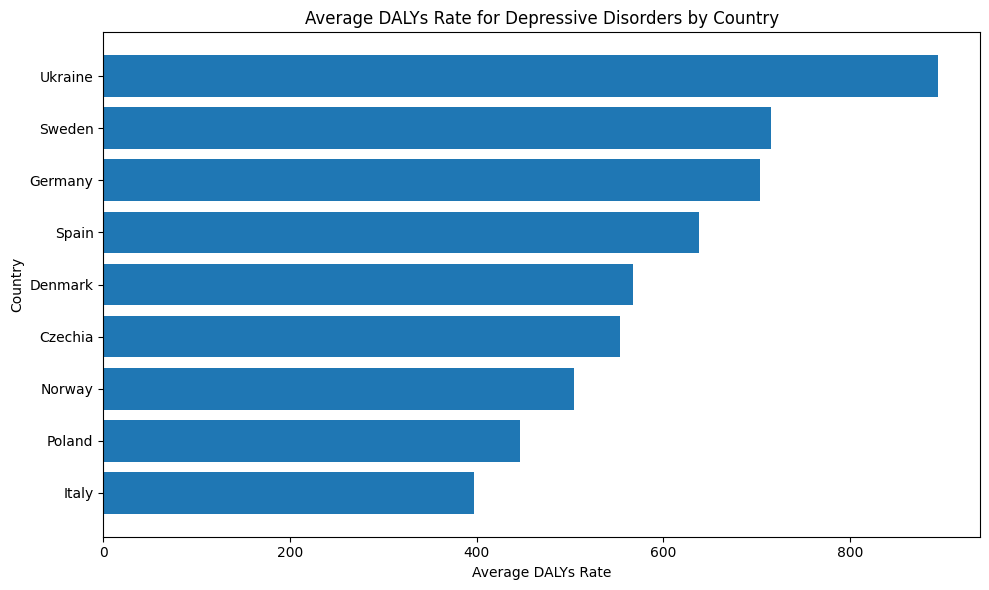

In [5]:
plt.figure(figsize=(10, 6))
plt.barh(df_dalys_country["country"], df_dalys_country["avg_dalys_rate"])
plt.gca().invert_yaxis()
plt.title("Average DALYs Rate for Depressive Disorders by Country")
plt.xlabel("Average DALYs Rate")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

The chart shows clear cross-country differences in the burden of depressive disorders.
Countries with higher average DALYs rates may represent markets where the need for effective antidepressant treatment is structurally stronger.

## Section 2 — Regional comparison of depression burden

### Question
Are there meaningful regional differences in depression burden across Europe?

In [6]:
query = """
SELECT
  CASE
    WHEN country IN ('Denmark', 'Norway', 'Sweden') THEN 'Scandinavia'
    WHEN country IN ('Germany', 'Spain', 'Italy') THEN 'Western Europe'
    WHEN country IN ('Poland', 'Czechia', 'Ukraine') THEN 'Eastern Europe'
    ELSE 'Other'
  END AS region,
  AVG(dalys_rate) AS avg_dalys_rate
FROM `lundbeck-market-analysis.lundbeck_data.dalys`
GROUP BY region
ORDER BY avg_dalys_rate DESC
"""

df_dalys_region = client.query(query).to_dataframe()
df_dalys_region

,region,avg_dalys_rate
0,Eastern Europe,631.273135
1,Scandinavia,595.608014
2,Western Europe,579.882954


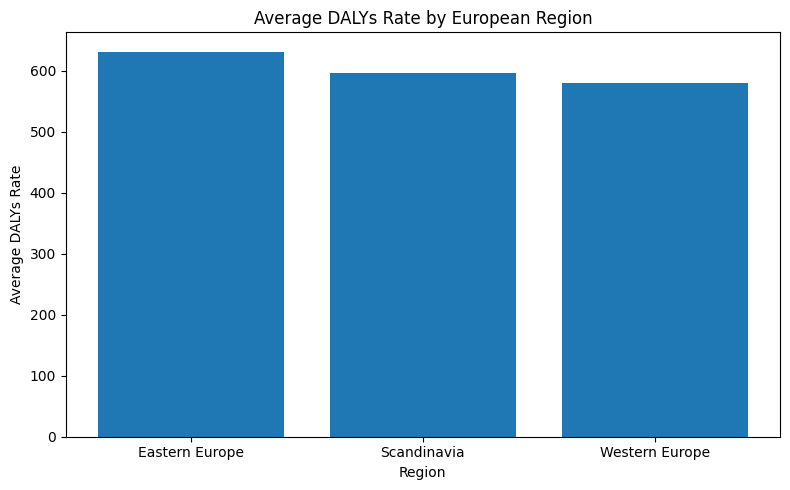

In [7]:
plt.figure(figsize=(8, 5))
plt.bar(df_dalys_region["region"], df_dalys_region["avg_dalys_rate"])
plt.title("Average DALYs Rate by European Region")
plt.xlabel("Region")
plt.ylabel("Average DALYs Rate")
plt.tight_layout()
plt.show()

Regional averages suggest that depression burden is not distributed evenly across Europe.
This comparison helps identify broader geographic patterns that may influence antidepressant demand and future market opportunities.
We can see that the highest rates are in Eastern Europe.

## Section 3 — Antidepressant consumption trend

### Question
How has antidepressant consumption evolved over time?

In [9]:
query_section_3 = """
SELECT
  year,
  AVG(ddd) AS avg_consumption
FROM `lundbeck-market-analysis.lundbeck_data.antidepressant_consumption`
GROUP BY year
ORDER BY year
"""
df_section_3 = client.query(query_section_3).to_dataframe()
df_section_3

,year,avg_consumption
0,2000,29.916667
1,2001,34.016667
2,2002,37.316667
3,2003,41.900000
4,2004,43.633333
5,2005,46.366667
6,2006,49.283333
7,2007,53.066667
8,2008,55.233333
9,2009,57.633333


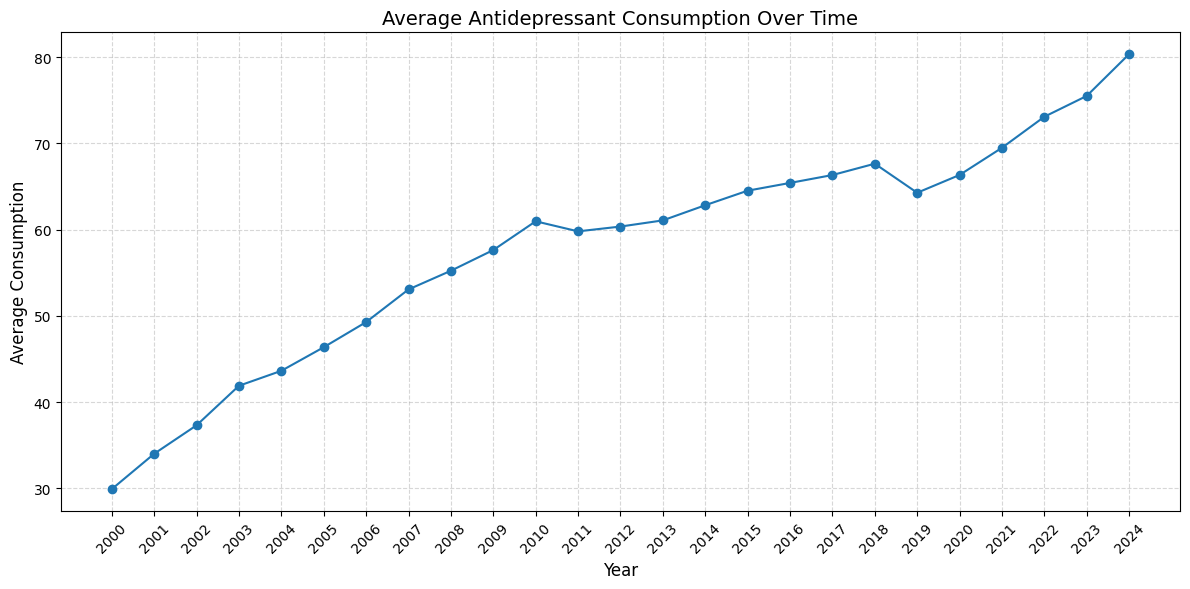

In [10]:
plt.figure(figsize=(12, 6))
plt.plot(
    df_section_3['year'],
    df_section_3['avg_consumption'],
    marker='o'
)

plt.title('Average Antidepressant Consumption Over Time', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Consumption', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(df_section_3['year'], rotation=45)
plt.tight_layout()

plt.show()

Average antidepressant consumption fluctuated over time, but the overall trend appears to be upward. This indicates that, despite short-term variations (in 2010 and 2018), antidepressant use generally increased across the observed years.

## Section 4 — Relationship between depression burden and consumption

### Question
Is there a relationship between depression burden and antidepressant consumption?

In [11]:
query_section_4 = """
SELECT
    d.country,
    d.year,
    d.dalys_rate AS dalys,
    c.ddd AS consumption
FROM `lundbeck-market-analysis.lundbeck_data.dalys` d
JOIN `lundbeck-market-analysis.lundbeck_data.antidepressant_consumption` c
    ON d.country = c.country
    AND d.year = c.year
"""
df_section_4 = client.query(query_section_4).to_dataframe()
df_section_4

,country,year,dalys,consumption
0,Czechia,2000,526.996537,9.7
1,Czechia,2001,555.037718,12.0
2,Czechia,2002,533.055910,14.1
3,Czechia,2003,533.646824,16.9
4,Czechia,2004,558.539719,20.2
...,...,...,...,...
157,Sweden,2019,720.562871,102.7
158,Sweden,2020,903.310203,105.5
159,Sweden,2021,825.284414,108.9
160,Sweden,2022,881.478552,114.5


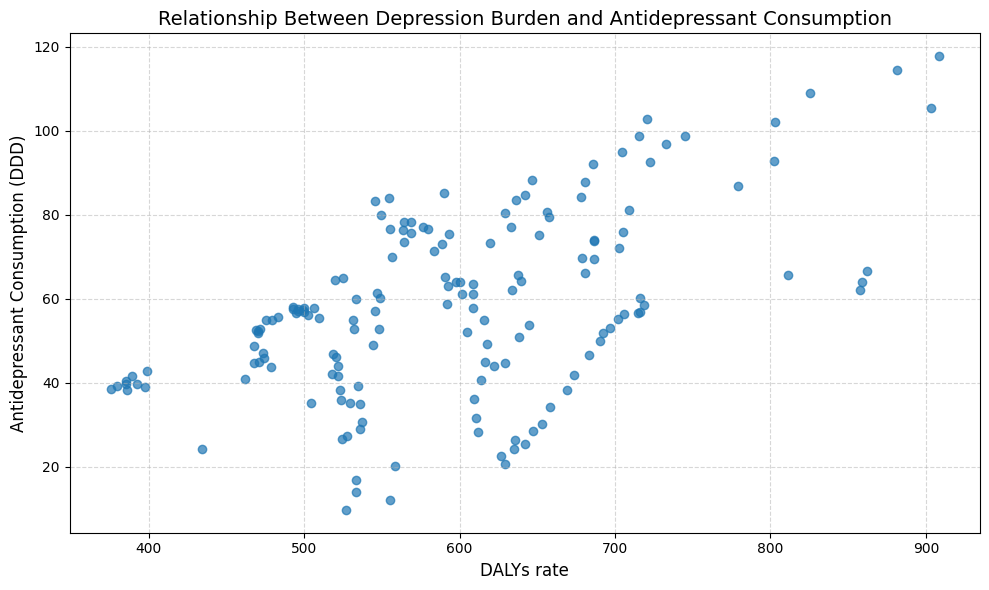

In [13]:
plt.figure(figsize=(10,6))
plt.scatter(
    df_section_4['dalys'],
    df_section_4['consumption'],
    alpha=0.7
)

plt.title('Relationship Between Depression Burden and Antidepressant Consumption', fontsize=14)
plt.xlabel('DALYs rate', fontsize=12)
plt.ylabel('Antidepressant Consumption (DDD)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [14]:
correlation = df_section_4['dalys'].corr(df_section_4['consumption'])
print(f'Correlation between DALYs and antidepressant consumption: {correlation:.3f}')

Correlation between DALYs and antidepressant consumption: 0.546


The scatter plot shows a moderate positive relationship between depression burden (DALYs rate) and antidepressant consumption (DDD).

The calculated correlation coefficient is approximately **0.55**, indicating that countries or years with a higher depression burden tend to have higher antidepressant consumption. However, the dispersion of the points suggests that this relationship is not perfectly linear and that other factors—such as healthcare access, prescribing practices, and mental health policies—may also influence antidepressant use.

## Section 5 — Market landscape

### Question
How does antidepressant consumption relate to the pharmaceutical market size across countries?

In [15]:
query_section_5 = """
SELECT
    c.country,
    AVG(c.ddd) AS avg_consumption,
    AVG(p.ppp_sales) AS avg_sales
FROM `lundbeck-market-analysis.lundbeck_data.antidepressant_consumption` c
JOIN `lundbeck-market-analysis.lundbeck_data.pharma_sales` p
    ON c.country = p.country
    AND c.year = p.year
GROUP BY c.country
ORDER BY avg_consumption DESC
"""
df_section_5 = client.query(query_section_5).to_dataframe()
df_section_5

,country,avg_consumption,avg_sales
0,Sweden,83.776000,461.148000
1,Denmark,72.564000,505.924000
2,Spain,71.676190,500.947619
3,Norway,55.764000,475.064000
4,Germany,45.679167,528.866667
5,Czechia,43.870833,559.916667
6,Italy,42.071429,564.057143
7,Poland,33.450000,218.450000


The table shows notable differences between antidepressant consumption and pharmaceutical market size across countries. Sweden has the highest antidepressant consumption, while Italy and Czechia exhibit the largest pharmaceutical markets. Poland shows the lowest values for both indicators.

These differences suggest that pharmaceutical market size does not always directly correspond to antidepressant consumption, and may be influenced by broader healthcare and market factors.

## Section 6 — Focus markets (Italy & Spain)

### Question
How has antidepressant consumption evolved in Lundbeck’s key markets, Italy and Spain?

In [18]:
query_section_6 = """
SELECT
    country,
    year,
    ddd
FROM `lundbeck-market-analysis.lundbeck_data.antidepressant_consumption`
WHERE country IN ('Italy','Spain')
ORDER BY year
"""
df_section_6 = client.query(query_section_6).to_dataframe()
df_section_6

,country,year,ddd
0,Spain,2000,28.2
1,Spain,2001,31.7
2,Spain,2002,36.1
3,Spain,2003,40.6
4,Spain,2004,44.1
5,Spain,2005,45.0
6,Spain,2006,49.2
7,Spain,2007,52.1
8,Spain,2008,55.0
9,Spain,2009,57.7


In [19]:
df_pivot_6 = df_section_6.pivot(
    index='year',
    columns='country',
    values='ddd'
)

df_pivot_6

country,Italy,Spain
year,,
2000,NaN,28.2
2001,NaN,31.7
2002,NaN,36.1
2003,NaN,40.6
2004,NaN,44.1
2005,NaN,45.0
2006,NaN,49.2
2007,NaN,52.1
2008,NaN,55.0


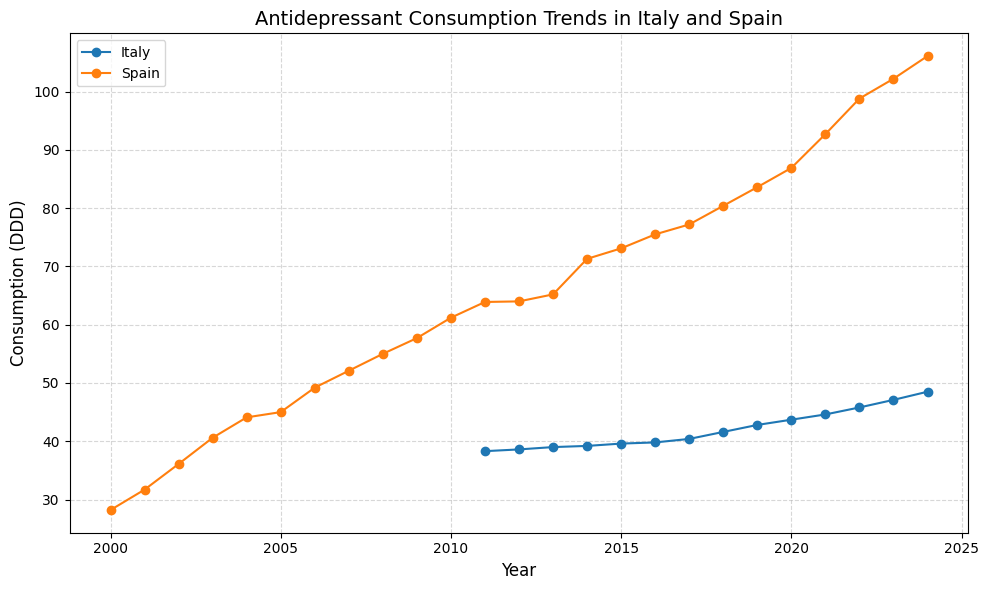

In [20]:
plt.figure(figsize=(10,6))

plt.plot(
    df_pivot_6.index,
    df_pivot_6['Italy'],
    marker='o',
    label='Italy'
)

plt.plot(
    df_pivot_6.index,
    df_pivot_6['Spain'],
    marker='o',
    label='Spain'
)

plt.title('Antidepressant Consumption Trends in Italy and Spain', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Consumption (DDD)', fontsize=12)

plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Antidepressant consumption has increased in both Italy and Spain over time. Spain shows significantly higher and faster growth in consumption, suggesting stronger market expansion compared to Italy.

## Section 7 — Emerging markets

### Question
Which countries appear as emerging markets based on the first year of available pharmaceutical sales data?

In [21]:
query_section_7 = """
SELECT
    country,
    MIN(year) AS first_available_year
FROM `lundbeck-market-analysis.lundbeck_data.pharma_sales`
GROUP BY country
ORDER BY first_available_year DESC
"""
df_section_7 = client.query(query_section_7).to_dataframe()
df_section_7

,country,first_available_year
0,Poland,2019
1,Italy,2011
2,Spain,2004
3,Denmark,2000
4,Sweden,2000
5,Norway,2000
6,Czechia,2000
7,Germany,2000


The table shows that most countries in the dataset have pharmaceutical sales data available since 2000, indicating established markets. Spain appears later, with data starting in 2004, while Italy and Poland have much more recent data availability, beginning in 2011 and 2019 respectively. This suggests that Italy and especially Poland may represent more recently tracked or emerging markets in the dataset.

## Section 8 — Ukraine case study

### Question
How has depression burden evolved in Ukraine?

In [24]:
query_section_8 = """
SELECT
    year,
    dalys_rate
FROM `lundbeck-market-analysis.lundbeck_data.dalys`
WHERE country = 'Ukraine'
ORDER BY year
"""
df_section_8 = client.query(query_section_8).to_dataframe()
df_section_8

,year,dalys_rate
0,2000,765.845655
1,2001,771.131592
2,2002,806.457445
3,2003,767.691745
4,2004,787.242649
5,2005,838.890843
6,2006,826.823340
7,2007,849.713442
8,2008,872.636016
9,2009,869.946973


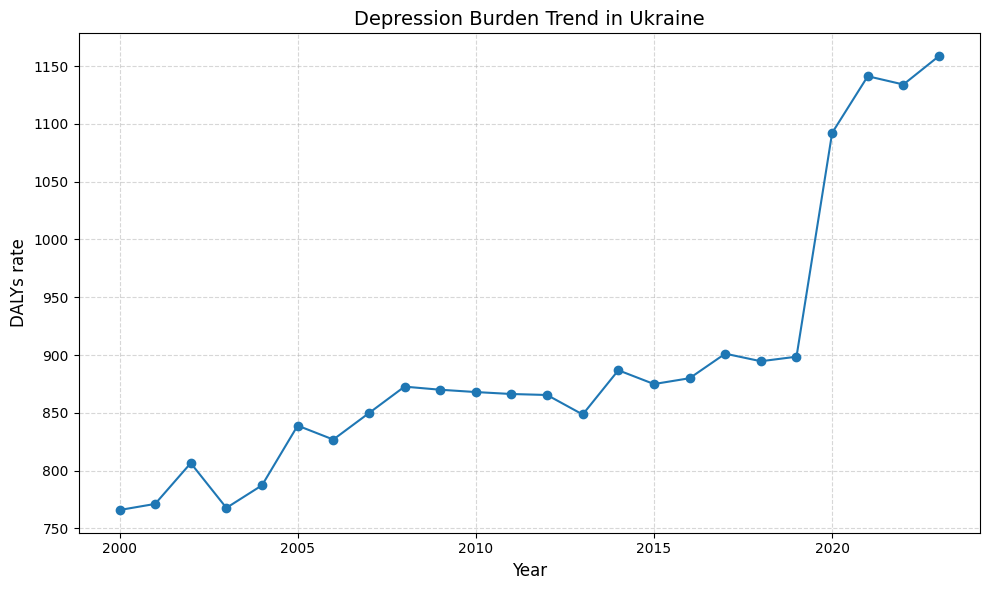

In [25]:
plt.figure(figsize=(10,6))

plt.plot(
    df_section_8['year'],
    df_section_8['dalys_rate'],
    marker='o'
)

plt.title('Depression Burden Trend in Ukraine', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('DALYs rate', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Depression burden in Ukraine remained relatively stable from 2000 to around 2019, fluctuating within a moderate range. A noticeable structural shift occurs after 2020, with a sharp increase in DALYs rates. The most significant rise appears after 2022, corresponding to the full-scale war, suggesting a substantial deterioration in population mental health during this period.

## Section 9 — Lundbeck revenue structure

### Question
What does Lundbeck’s revenue structure look like across its key products?

In [26]:
from google.colab import files
uploaded = files.upload()

Saving lundbeck_2023_revenue_table.csv to lundbeck_2023_revenue_table.csv


In [29]:
import pandas as pd

df_revenue_2023 = pd.read_csv('lundbeck_2023_revenue_table.csv')
df_revenue_2023

,TOTAL REVENUE,2023,2022,Growth,Growth (CER)
0,Rexulti®/Rxulti®,"4,525","3,890",16%,20%
1,Brintellix®/Trintellix®,"4,324","4,277",1%,5%
2,Abilify Maintena®/Asimtufii,"3,187","2,964",8%,10%
3,Vyepti®,"1,697","1,004",69%,74%
4,Strategic brands,"13,733","12,135",13%,16%
5,Cipralex®/Lexapro®,"2,135","2,360",(10%),(4%)
6,Sabril®,336,636,(47%),(47%)
7,Other pharmaceuticals,"3,244","3,426",(5%),(2%)
8,Mature brands,"5,715","6,422",(11%),(7%)
9,Other revenue,327,277,18%,18%


In [30]:
df_revenue_2023 = df_revenue_2023.rename(columns={'TOTAL REVENUE':'drug'})

In [38]:
df_drugs_2023 = df_revenue_2023[
    ~df_revenue_2023['drug'].isin([
        'Strategic brands',
        'Mature brands',
        'Other revenue',
        'Total revenue before hedging',
        'Effects from hedging',
        'Total revenue'
    ])
]
df_drugs_2023 = df_drugs_2023.sort_values('2023', ascending=False)
df_drugs_2023

,drug,2023,2022,Growth,Growth (CER)
0,Rexulti®/Rxulti®,4525.0,"3,890",16%,20%
1,Brintellix®/Trintellix®,4324.0,"4,277",1%,5%
7,Other pharmaceuticals,3244.0,"3,426",(5%),(2%)
2,Abilify Maintena®/Asimtufii,3187.0,"2,964",8%,10%
5,Cipralex®/Lexapro®,2135.0,"2,360",(10%),(4%)
3,Vyepti®,1697.0,"1,004",69%,74%
6,Sabril®,336.0,636,(47%),(47%)


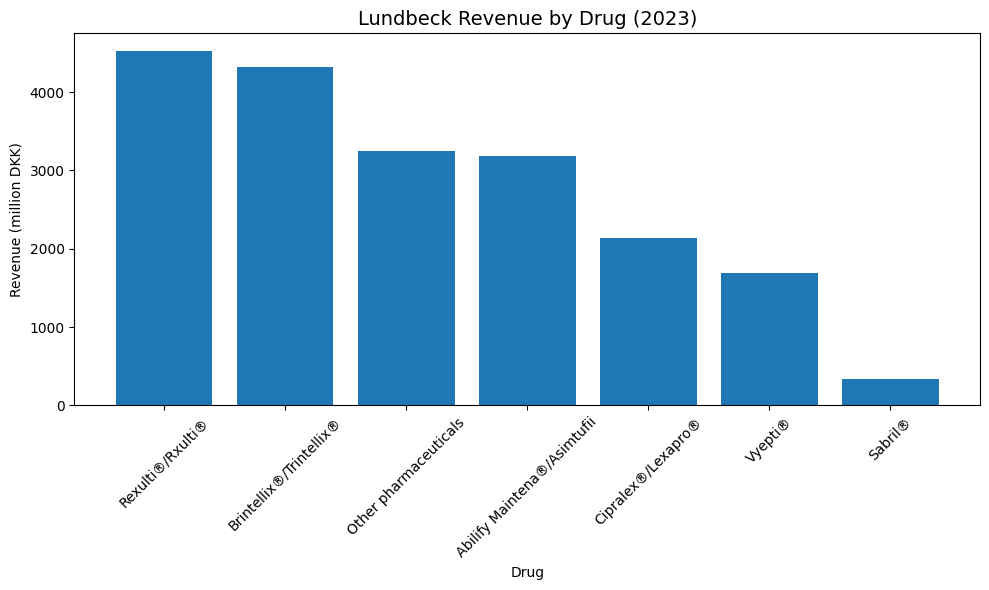

In [39]:
plt.figure(figsize=(10,6))

plt.bar(
    df_drugs_2023['drug'],
    df_drugs_2023['2023']
)

plt.title('Lundbeck Revenue by Drug (2023)', fontsize=14)
plt.xlabel('Drug')
plt.ylabel('Revenue (million DKK)')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [40]:
from google.colab import files
uploaded = files.upload()

Saving lundbeck_2024_revenue_table.csv to lundbeck_2024_revenue_table.csv


In [41]:
df_revenue_2024 = pd.read_csv('lundbeck_2024_revenue_table.csv')
df_revenue_2024

,TOTAL REVENUE,2024,2023,Growth (CER),Growth
0,Rexulti®,"5,202","4,525",16%,15%
1,Brintellix®/Trintellix®,"4,847","4,324",14%,12%
2,Abilify LAI franchise,"3,504","3,187",10%,10%
3,Vyepti®,"2,909","1,697",72%,71%
4,Strategic brands,"16,462","13,733",21%,20%
5,Cipralex®/Lexapro®,"2,048","2,135",2%,(4%)
6,Other pharmaceuticals,"3,180","3,580",(9%),(11%)
7,Mature brands,"5,228","5,715",(5%),(9%)
8,Other revenue,366,327,12%,12%
9,Total revenue before hedging,"22,056","19,775",14%,12%


In [42]:
df_revenue_2024 = df_revenue_2024.rename(columns={'TOTAL REVENUE':'drug'})

In [43]:
df_revenue_2024['2024'] = (
    df_revenue_2024['2024']
    .astype(str)
    .str.replace(',', '')
    .str.replace('(', '-')
    .str.replace(')', '')
    .astype(float)
)

In [44]:
df_drugs_2024 = df_revenue_2024[
    ~df_revenue_2024['drug'].isin([
        'Strategic brands',
        'Mature brands',
        'Other revenue',
        'Total revenue before hedging',
        'Effects from hedging',
        'Total revenue'
    ])
]
df_drugs_2024 = df_drugs_2024.sort_values('2024', ascending=False)
df_drugs_2024

,drug,2024,2023,Growth (CER),Growth
0,Rexulti®,5202.0,"4,525",16%,15%
1,Brintellix®/Trintellix®,4847.0,"4,324",14%,12%
2,Abilify LAI franchise,3504.0,"3,187",10%,10%
6,Other pharmaceuticals,3180.0,"3,580",(9%),(11%)
3,Vyepti®,2909.0,"1,697",72%,71%
5,Cipralex®/Lexapro®,2048.0,"2,135",2%,(4%)


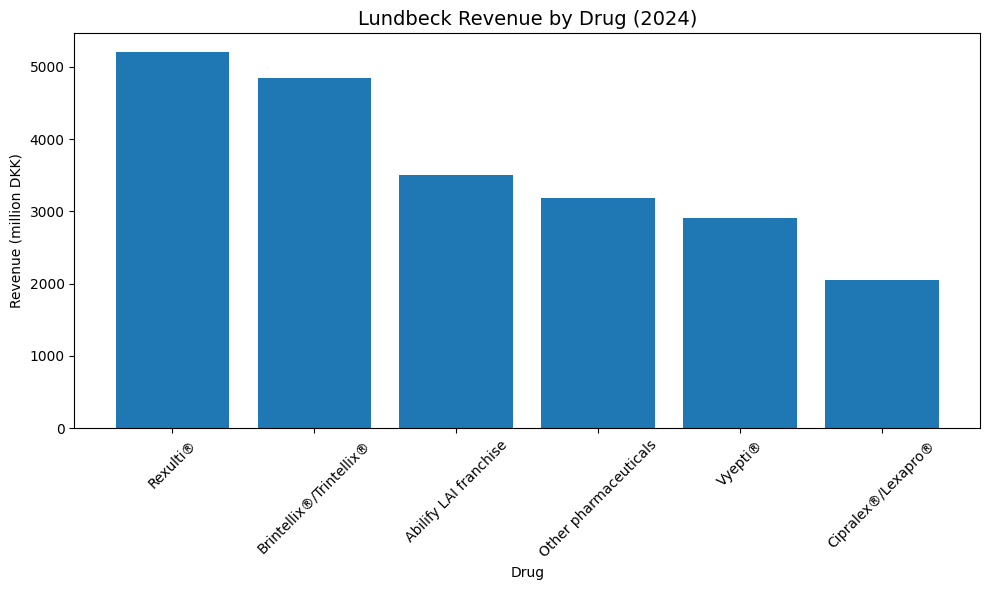

In [46]:
plt.figure(figsize=(10,6))

plt.bar(
    df_drugs_2024['drug'],
    df_drugs_2024['2024']
)

plt.title('Lundbeck Revenue by Drug (2024)', fontsize=14)
plt.xlabel('Drug')
plt.ylabel('Revenue (million DKK)')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [47]:
df_compare = pd.merge(
    df_drugs_2023[['drug','2023']],
    df_drugs_2024[['drug','2024']],
    on='drug'
)

df_compare

,drug,2023,2024
0,Brintellix®/Trintellix®,4324.0,4847.0
1,Other pharmaceuticals,3244.0,3180.0
2,Cipralex®/Lexapro®,2135.0,2048.0
3,Vyepti®,1697.0,2909.0


In [48]:
df_compare['growth_%'] = (
    (df_compare['2024'] - df_compare['2023']) /
    df_compare['2023'] * 100
).round(1)

df_compare

,drug,2023,2024,growth_%
0,Brintellix®/Trintellix®,4324.0,4847.0,12.1
1,Other pharmaceuticals,3244.0,3180.0,-2.0
2,Cipralex®/Lexapro®,2135.0,2048.0,-4.1
3,Vyepti®,1697.0,2909.0,71.4


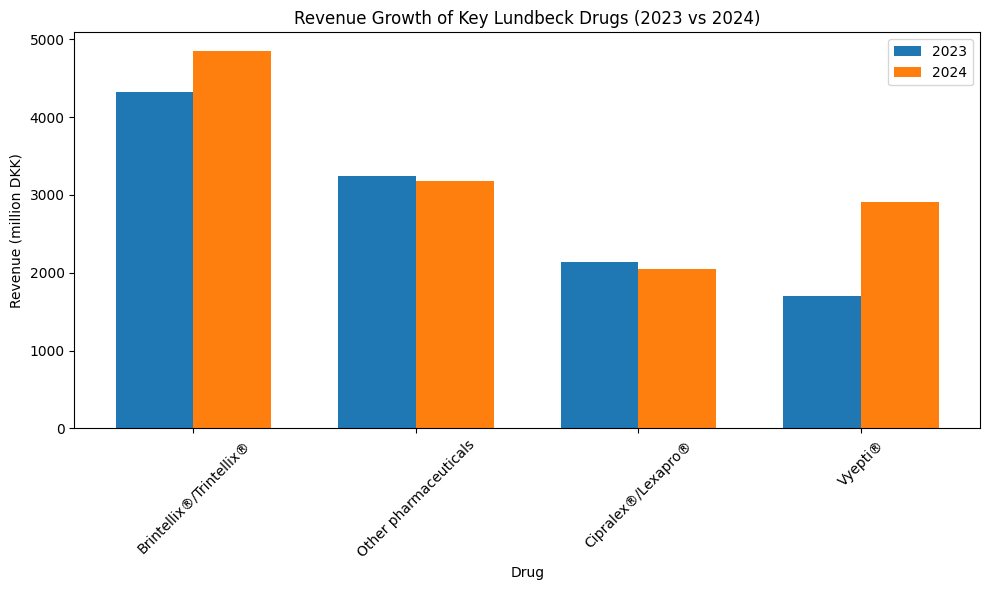

In [49]:
import numpy as np

x = np.arange(len(df_compare['drug']))
width = 0.35

plt.figure(figsize=(10,6))

plt.bar(x - width/2, df_compare['2023'], width, label='2023')
plt.bar(x + width/2, df_compare['2024'], width, label='2024')

plt.xticks(x, df_compare['drug'], rotation=45)

plt.title('Revenue Growth of Key Lundbeck Drugs (2023 vs 2024)')
plt.xlabel('Drug')
plt.ylabel('Revenue (million DKK)')

plt.legend()

plt.tight_layout()
plt.show()

Brintellix acts as Lundbeck’s primary growth driver, demonstrating continued revenue expansion. Cipralex, in contrast, reflects a mature product facing strong generic competition.

However, as the originator brand of escitalopram, Cipralex benefits from long-established clinical credibility and physician trust. Even in markets with widespread generics, originator drugs often maintain a stable niche due to perceived reliability and brand recognition. Therefore, maintaining commercial support for Cipralex alongside the promotion of Brintellix may help Lundbeck preserve value within the mature segment of the antidepressant market.

## Section 10 — Exploratory ML: Predicting consumption growth

In [50]:
query_ml = """
SELECT
d.country,
d.year,
d.dalys_rate,
c.ddd AS consumption
FROM `lundbeck-market-analysis.lundbeck_data.dalys` d
JOIN `lundbeck-market-analysis.lundbeck_data.antidepressant_consumption` c
ON d.country = c.country
AND d.year = c.year
"""
df_ml = client.query(query_ml).to_dataframe()

In [51]:
df_ml = df_ml.sort_values(['country','year'])

df_ml['consumption_growth'] = (
    df_ml.groupby('country')['consumption']
    .diff() > 0
).astype(int)

df_ml = df_ml.dropna()

In [52]:
X = df_ml[['dalys_rate','year']]
y = df_ml['consumption_growth']

In [53]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [54]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [55]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

accuracy_score(y_test, y_pred)

0.8181818181818182

A simple logistic regression model was used to predict whether antidepressant consumption would increase based on DALYs rates and year. The model achieved an accuracy of approximately **82%**, indicating that these variables contain useful information for predicting consumption trends.

This result supports the earlier exploratory analysis suggesting that higher depression burden and temporal trends are associated with increasing antidepressant consumption. However, the model is intentionally simple and does not account for other important factors such as healthcare policies, pricing, or market dynamics.

## Key Insights

The analysis highlights several important trends in the European antidepressant market and Lundbeck’s product portfolio.

First, the burden of depression remains substantial across European countries and has shown gradual increases in several regions. This suggests that the underlying demand for mental health treatment is likely to remain strong in the coming years.

Second, antidepressant consumption has generally increased over time. The relationship observed between DALYs and consumption indicates that higher depression burden tends to be associated with higher medication use, suggesting that epidemiological trends partially translate into pharmaceutical demand.

Third, market dynamics vary significantly across countries. Some markets demonstrate both high antidepressant consumption and strong pharmaceutical sales, while others show potential for expansion. This indicates that market structure, healthcare systems, and prescribing practices strongly influence treatment uptake.

Fourth, country-level analysis highlights meaningful differences between key markets. Spain shows significantly higher antidepressant consumption growth compared to Italy, indicating stronger expansion of treatment usage in that market.

Finally, Lundbeck’s revenue structure illustrates a clear shift within its antidepressant portfolio. Newer products such as **Brintellix** are growing and becoming increasingly important revenue drivers, while older products such as **Cipralex** belong to the mature segment and face stronger competition from generic alternatives.

## Strategic Recommendations for Lundbeck

Based on the analysis, several strategic considerations emerge for Lundbeck’s antidepressant portfolio.

**1. Continue positioning Brintellix as the primary growth driver.**  
Brintellix shows strong revenue growth and represents a key innovation-driven asset within Lundbeck’s portfolio. Continued investment in physician education, clinical differentiation, and market expansion could further strengthen its position as a leading modern antidepressant.

**2. Maintain selective support for Cipralex despite generic competition.**  
Although Cipralex faces declining revenue due to widespread generics, it remains the original branded formulation of escitalopram. Originator drugs often retain a stable niche due to long-standing physician trust and perceived reliability. Maintaining targeted promotion in key markets may help preserve value from this mature product.

**3. Focus on high-growth markets.**  
Countries with rapidly increasing antidepressant consumption, such as Spain, may offer strong opportunities for further portfolio expansion.

**4. Monitor emerging markets.**  
Markets with more recent pharmaceutical sales data may represent opportunities for future growth as treatment access expands.

**5. Align portfolio strategy with epidemiological trends.**  
The positive relationship between depression burden and antidepressant consumption suggests that future demand will continue to be influenced by population mental health trends. Monitoring these indicators can help anticipate market expansion opportunities.

### Expansion Opportunity: Ukraine

The analysis also suggests that Ukraine may represent a promising future market for Lundbeck’s antidepressant portfolio.

First, epidemiological indicators point to a significant increase in the burden of depression, particularly after 2022. This trend suggests growing demand for mental health treatment and long-term antidepressant therapy.

Second, recent market data indicate rapidly increasing pharmaceutical demand. According to a study cited by Forbes, demand for antidepressants in Ukraine increased by **72% between 2023 and 2025**, with year-over-year growth of about 25% in 2025 alone.

https://forbes.ua/news/za-dva-ostanni-roki-popit-na-antidepresanti-v-ukraini-zris-na-72-doslidzhennya-liki24-05022026-36090?utm_source=chatgpt.com

Third, government policy is improving access to antidepressant treatment. The Ukrainian reimbursement program ("Affordable Medicines") continues to expand, allowing patients to receive certain prescription medicines free of charge or with partial co-payment through the National Health Service of Ukraine. The inclusion of antidepressants such as escitalopram in reimbursement lists further increases accessibility and potential market uptake.

https://unn.ua/en/news/in-ukraine-a-six-month-volume-of-e-prescriptions-for-mental-health-medications-was-issued-in-4-months

Taken together, the combination of increasing mental health burden, rapidly growing demand for antidepressants, and expanding reimbursement coverage suggests that Ukraine may become an important growth market for antidepressant therapies. For Lundbeck, this creates an opportunity to strengthen the presence of both **Brintellix as a growth product** and **Cipralex as a trusted originator escitalopram brand**.

## Key Market Indicators

| Indicator | Key Insight |
|---|---|
Depression burden | Increasing across several markets |
Antidepressant consumption | Long-term upward trend |
DALYs vs consumption | Moderate positive relationship |
Brintellix revenue | Strong growth |
Cipralex revenue | Mature product with declining trend |
Ukraine market | Rapid demand growth and policy support |

## Final Strategic Conclusion

This analysis highlights a clear link between the burden of depression and the growth of antidepressant consumption across markets. As mental health challenges continue to increase, demand for effective pharmacological treatments is expected to remain strong.

Within Lundbeck’s portfolio, **Brintellix emerges as the primary growth driver**, demonstrating strong revenue expansion and strategic importance for future market development. **Cipralex, while facing generic competition, continues to retain value as the originator escitalopram brand**, benefiting from long-standing clinical trust and brand recognition.

At the same time, emerging markets such as **Ukraine present a significant long-term opportunity**, driven by rising depression burden, rapidly growing demand for antidepressants, and expanding reimbursement policies that improve patient access to treatment.

Taken together, these findings suggest that Lundbeck’s optimal strategy should combine **continued investment in innovative growth products such as Brintellix with selective support for mature but trusted therapies like Cipralex**, while actively exploring expansion into high-growth markets.

## Limitations

This analysis is based on publicly available datasets and simplified market indicators. The results do not account for factors such as pricing strategies, national prescribing policies, marketing investments, or detailed competitive dynamics between branded and generic products.

Therefore, the findings should be interpreted as exploratory insights rather than precise market forecasts.